# Study 778 — Chipotle-Scare — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `846252f83830`. **Read every *t* through the n = 6 / one-2015-crisis / overlapping-December-windows caveat.**

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from chipotle_scare import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching CMG + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} scares resolved")


panel loaded; 6 of 6 scares resolved


## 1. One-sample *t* across the scare events

Each scare is one event, so the unit is a one-sample *t* of the per-event abnormal return — **not** a daily panel (which would fake precision). The claim ('buy the dip') is a *positive* post-event (rebound) mean.

In [2]:
for label, col in [('2wk shock','pre_s'),('1mo shock','pre_l'),('1mo rebound','post_s'),('1q rebound','post_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<12s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk shock    n=6  mean=-3.877%  sd=2.75%  t=-3.451
1mo shock    n=6  mean=-9.806%  sd=9.10%  t=-2.640
1mo rebound  n=6  mean=-9.329%  sd=9.70%  t=-2.355
1q rebound   n=6  mean=-10.111%  sd=13.20%  t=-1.877


## 2. Random-window placebo — is the keep-falling drift inside the luck cloud?

For each event we redraw a random, non-scare one-month window on CMG vs SPY and recompute the abnormal return; 20 seeds × 200 draws. The buy-the-dip claim is the *right* tail (a positive rebound); the observed rebound sits at the far *left*.

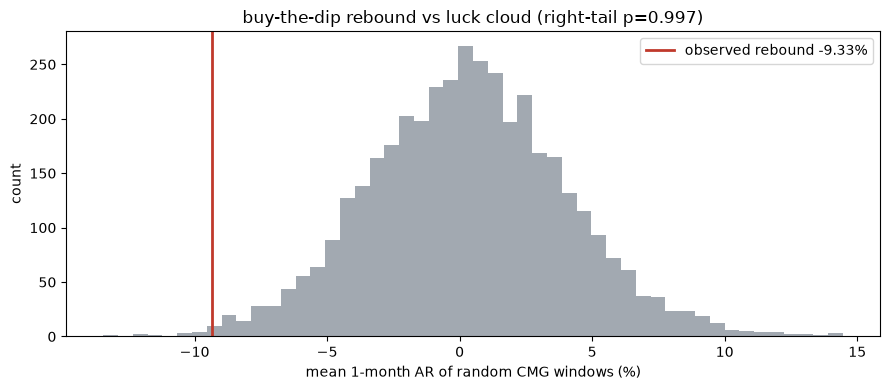

placebo: {'obs': -0.0933, 'placebo_mean': 0.0022, 'placebo_sd': 0.0372, 'p_value': 0.9968, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'post_s', k=21, tail='right')
aapl_cmg, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = aapl_cmg.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-22))
        vals.append(float(aapl_cmg.loc[common[p+21]]/aapl_cmg.loc[common[p]] - spy.loc[common[p+21]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#c0392b', lw=2, label=f"observed rebound {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 1-month AR of random CMG windows (%)'); ax.set_ylabel('count')
ax.set_title(f"buy-the-dip rebound vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the drift one bad year, or broad?

The jackknife *t* never leaves negative territory — but that is **not** real robustness: four of six events are the single 2015 crisis, so leave-one-out can't break the dependence.

In [4]:
x = inc['post_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = -2.355
jackknife t range [-4.027, -1.742] over 6 leave-one-out draws


## 4. Tradability — net of costs

'Buy the dip' loses ~9–10% of abnormal return per event *before* borrow. The inverse (short the scare, keep shorting) 'works' in-sample, but on 6 events across 11 years, one 2015 crisis, in a hard-to-borrow single name — capacity-trivial and un-bankable.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('post_s','1mo rebound'),('post_l','1q rebound')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<12s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

1mo rebound  gross -9.329% (t=-2.36)  net@5 -9.429% (t=-2.38)  net@10 -9.529% (t=-2.41)
1q rebound   gross -10.111% (t=-1.88)  net@5 -10.211% (t=-1.90)  net@10 -10.311% (t=-1.91)


## 5. Synthetic positive control — the detector works, the null is quiet

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted buy-the-dip rebound. It does both — so the *absence* of a rebound on the real tape is informative, not a dead detector.

null: mean t=-0.29 sd=0.76  |t|>=2 in 0/20 seeds
planted rebound +3%: mean AR +2.768%  t=+2.17
planted rebound +6%: mean AR +5.768%  t=+4.52


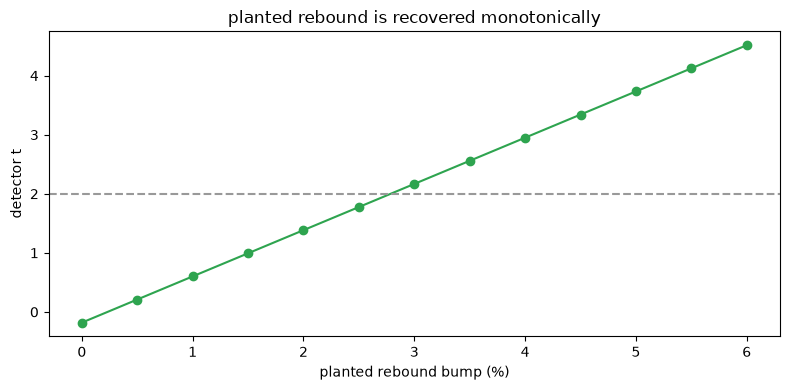

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=784+s, k=10, side='post')['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.03, 0.06):
    r = st.synthetic_detect(bump=b, seed=784, k=10, side='post')
    print(f'planted rebound +{b*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.06, 13)
ts = [st.synthetic_detect(bump=b, seed=784, k=10, side='post')['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#2ea44f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted rebound bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted rebound is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The *claimed* effect — a positive buy-the-dip rebound — is decisively absent; the rebound is negative (−9.3%, *t* = −2.36, right-tail p ≈ 0.997), the reverse of the folklore. There's a suggestive keep-falling downdrift, but it's fragile: n = 6, four of them one autocorrelated 2015 crisis, two December windows overlapping. Not noise, not robust. **Tradability: Mirage.** 'Buy the dip' loses money net; the inverse short is a 6-event, one-episode, hard-to-borrow curiosity with no capacity and no independence — nothing to bank.